In [ ]:
# Importación de librerias
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
import seaborn as sns
import IPython.display as ipd
import urllib.request
import zipfile

In [ ]:
# Parte 1. Exploración del conjunto de datos
DATASET_DIR = pathlib.Path('/content/mini_speech_commands')

if not DATASET_DIR.exists():
    zip_path = '/content/mini_speech_commands.zip'
    url = "http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"

    print("Descargando dataset...")
    urllib.request.urlretrieve(url, zip_path)

    print("Extrayendo...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

# Verificar qué se extrajo realmente
print("Contenido de /content/:")
print(os.listdir('/content/'))

data_dir = DATASET_DIR
print("\nRuta del dataset:", data_dir)
print("¿Existe?", data_dir.exists())

if data_dir.exists():
    print("Contenido:", os.listdir(data_dir))

# Identificar las clases disponibles
commands = np.array([item.name for item in data_dir.iterdir()
                      if item.is_dir() and item.name != 'README.md'])
print("Clases disponibles:", commands)

filenames = tf.io.gfile.glob(str(data_dir) + '/*/*.wav')
filenames = tf.random.shuffle(filenames)
print("Número total de ejemplos:", len(filenames))

Descargando dataset...
Extrayendo...
Contenido de /content/:
['.config', 'mini_speech_commands', 'mini_speech_commands.zip', '__MACOSX', 'sample_data']

Ruta del dataset: /content/mini_speech_commands
¿Existe? True
Contenido: ['up', 'stop', 'README.md', 'yes', 'right', 'no', 'down', 'go', 'left']
Clases disponibles: ['up' 'stop' 'yes' 'right' 'no' 'down' 'go' 'left']
Número total de ejemplos: 8000


In [ ]:
import pandas as pd
df_resumen = pd.DataFrame(list(resumen_clases.items()), columns=['Clase', 'Cantidad de audios'])
df_resumen['Porcentaje'] = (df_resumen['Cantidad de audios'] / total_audios * 100).round(2)
df_resumen = df_resumen.sort_values('Cantidad de audios', ascending=False).reset_index(drop=True)

print(df_resumen)

   Clase  Cantidad de audios  Porcentaje
0     up                1000        12.5
1   stop                1000        12.5
2    yes                1000        12.5
3  right                1000        12.5
4     no                1000        12.5
5   down                1000        12.5
6     go                1000        12.5
7   left                1000        12.5


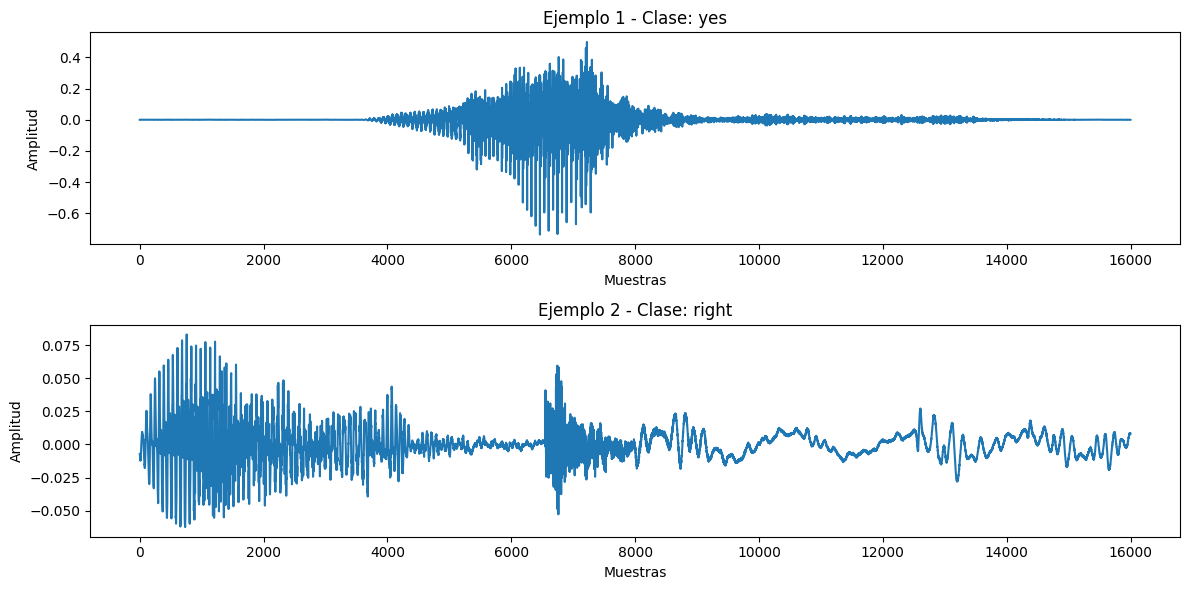

In [ ]:
# Visualizar ejemplos de señales de audio
def decode_audio(audio_binary):
    audio, sample_rate = tf.audio.decode_wav(contents=audio_binary)
    return tf.squeeze(audio, axis=-1), sample_rate

sample_files = filenames[:2].numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for i, file_path in enumerate(sample_files):
    audio_binary = tf.io.read_file(file_path)
    audio, sr = decode_audio(audio_binary)
    label = pathlib.Path(file_path.decode()).parent.name
    axes[i].plot(audio.numpy())
    axes[i].set_title(f"Ejemplo {i+1} - Clase: {label}")
    axes[i].set_xlabel("Muestras")
    axes[i].set_ylabel("Amplitud")
plt.tight_layout()
plt.show()

In [ ]:
# Reproducir algunas grabaciones
for file_path in sample_files:
    label = pathlib.Path(file_path.decode()).parent.name
    print(f"Reproduciendo: {label}")
    ipd.display(ipd.Audio(file_path.decode()))

Reproduciendo: yes


Reproduciendo: right


# Parte 2. Preprocesamiento

In [ ]:
# Parámetros generales
SAMPLE_RATE = 16000
AUTOTUNE = tf.data.AUTOTUNE

def decode_audio(audio_binary):
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1, desired_samples=SAMPLE_RATE)
    return tf.squeeze(audio, axis=-1)

def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    return parts[-2]  # nombre de la carpeta = clase

def get_waveform_and_label(file_path):
    label = get_label(file_path)
    audio_binary = tf.io.read_file(file_path)
    waveform = decode_audio(audio_binary)
    return waveform, label

def get_spectrogram(waveform):
    # Transformada de Fourier de Tiempo Corto
    # Aseguramos longitud fija (pad/truncate a 1 segundo = 16000 muestras)
    input_len = SAMPLE_RATE
    waveform = waveform[:input_len]
    zero_padding = tf.zeros([input_len] - tf.shape(waveform), dtype=tf.float32)
    waveform = tf.cast(waveform, tf.float32)
    equal_length = tf.concat([waveform, zero_padding], 0)

    spectrogram = tf.signal.stft(equal_length, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, -1)  # canal para la CNN
    return spectrogram

def get_spectrogram_and_label_id(audio, label):
    spectrogram = get_spectrogram(audio)
    label_id = tf.argmax(label == commands)
    return spectrogram, label_id

def preprocess_dataset(files):
    files_ds = tf.data.Dataset.from_tensor_slices(files)
    output_ds = files_ds.map(get_waveform_and_label, num_parallel_calls=AUTOTUNE)
    output_ds = output_ds.map(get_spectrogram_and_label_id, num_parallel_calls=AUTOTUNE)
    return output_ds

In [ ]:
n = len(filenames)
train_files = filenames[:int(0.8*n)]
val_files   = filenames[int(0.8*n):int(0.9*n)]
test_files  = filenames[int(0.9*n):]

print("Train:", len(train_files), "Val:", len(val_files), "Test:", len(test_files))

train_ds = preprocess_dataset(train_files)
val_ds   = preprocess_dataset(val_files)
test_ds  = preprocess_dataset(test_files)

batch_size = 64
train_ds = train_ds.batch(batch_size).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.batch(batch_size).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.batch(batch_size).cache().prefetch(AUTOTUNE)

# Ver forma del espectrograma
for spec, lbl in train_ds.take(1):
    input_shape = spec.shape[1:]
    print("Input shape:", input_shape)

Train: 6400 Val: 800 Test: 800
Input shape: (124, 129, 1)


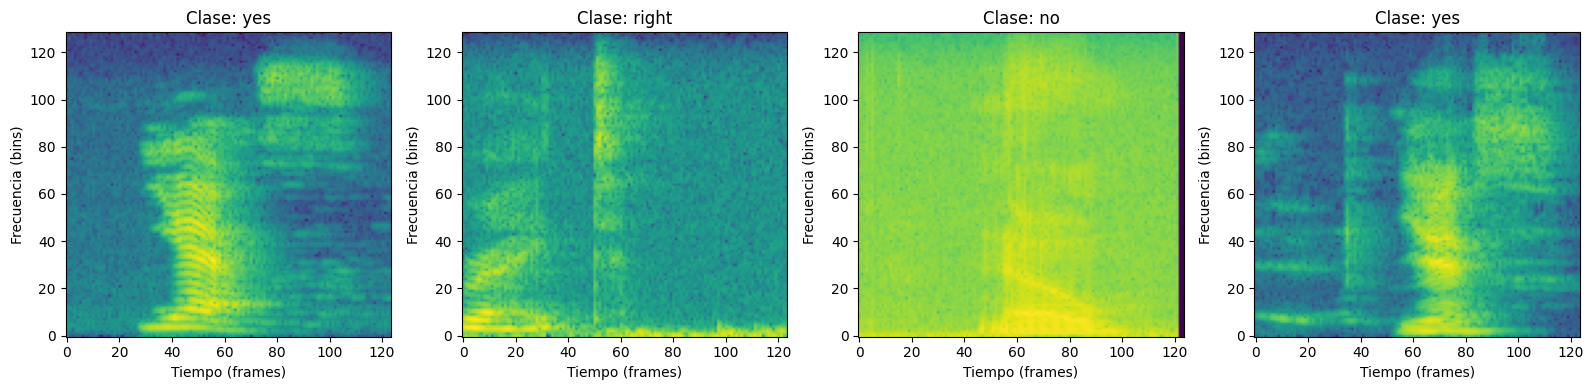

In [ ]:
def plot_spectrogram(spectrogram, ax):
    # spectrogram shape: (tiempo, frecuencia, 1) -> quitamos el canal
    spectrogram = np.squeeze(spectrogram, axis=-1)
    # Escala logarítmica para que se vea mejor (como en un espectrograma real)
    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    ax.imshow(log_spec, aspect='auto', origin='lower', cmap='viridis')

# Tomar un batch y graficar algunos ejemplos
for spec_batch, label_batch in train_ds.take(1):
    n_examples = 4
    fig, axes = plt.subplots(1, n_examples, figsize=(16, 4))
    for i in range(n_examples):
        plot_spectrogram(spec_batch[i].numpy(), axes[i])
        axes[i].set_title(f"Clase: {commands[label_batch[i].numpy()]}")
        axes[i].set_xlabel("Tiempo (frames)")
        axes[i].set_ylabel("Frecuencia (bins)")
    plt.tight_layout()
    plt.show()

# Parte 3. Construcción del modelo

In [ ]:
num_labels = len(commands)

# Capa de normalización adaptada al espectrograma
norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(train_ds.map(lambda x, y: x))

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(64, 64),
    norm_layer,
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_labels, activation='softmax')
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 64, 64, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,307 (4.36 MB)

 Trainable params: 1,142,856 (4.36 MB)

 Non-trainable params: 451 (1.77 KB)

#  Parte 4. Entrenamiento del modelo

In [ ]:
EPOCHS = 30

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.3142 - loss: 2.0718 - val_accuracy: 0.1725 - val_loss: 2.0417 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5011 - loss: 1.3298 - val_accuracy: 0.1925 - val_loss: 2.4011 - learning_rate: 0.0010
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6208 - loss: 1.0127 - val_accuracy: 0.3150 - val_loss: 2.0195 - learning_rate: 0.0010
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7141 - loss: 0.7770 - val_accuracy: 0.5350 - val_loss: 1.3659 - learning_rate: 0.0010
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7759 - loss: 0.6229 - val_accuracy: 0.5913 - val_loss: 1.4228 - learning_rate: 0.0010
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8172 - loss: 0.5271 - val_accuracy: 0.7200 - val_loss: 0.9672 - learning_rate: 0.0010
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8400 - loss: 0

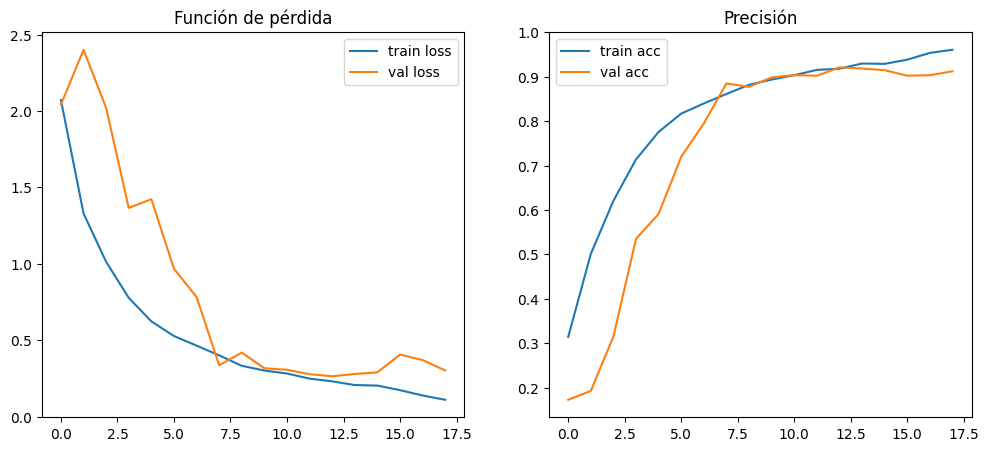

In [ ]:
# Gráficas de evolución
metrics_hist = history.history
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(metrics_hist['loss'], label='train loss')
plt.plot(metrics_hist['val_loss'], label='val loss')
plt.legend()
plt.title('Función de pérdida')

plt.subplot(1,2,2)
plt.plot(metrics_hist['accuracy'], label='train acc')
plt.plot(metrics_hist['val_accuracy'], label='val acc')
plt.legend()
plt.title('Precisión')
plt.show()

# Parte 5. Evaluación del modelo

In [ ]:
test_audio = []
test_labels = []

for spec, lbl in test_ds:
    test_audio.append(spec.numpy())
    test_labels.append(lbl.numpy())

test_audio = np.concatenate(test_audio, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

y_pred_probs = model.predict(test_audio)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = np.mean(y_pred == test_labels)
print(f"Precisión en test: {test_acc:.2%}")

print("\nReporte de clasificación:")
print(classification_report(test_labels, y_pred, target_names=commands))


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Precisión en test: 90.75%

Reporte de clasificación:
              precision    recall  f1-score   support

          up       0.83      0.98      0.90        97
        stop       0.98      0.94      0.96       107
         yes       0.92      0.92      0.92        91
       right       0.98      0.91      0.94       103
          no       0.91      0.88      0.89       100
        down       0.90      0.88      0.89       105
          go       0.86      0.84      0.85       110
        left       0.90      0.92      0.91        87

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



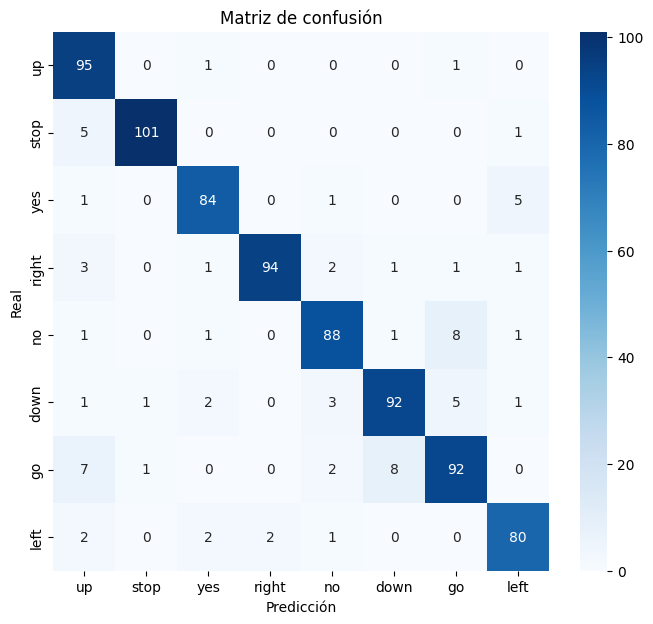

In [ ]:

cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=commands, yticklabels=commands, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

#  Parte 6: Prueba con nuevos comandos

Saving Pausa down.ogg to Pausa down.ogg
Archivo: Pausa down.ogg
Predicción: go  (confianza: 60.54%)


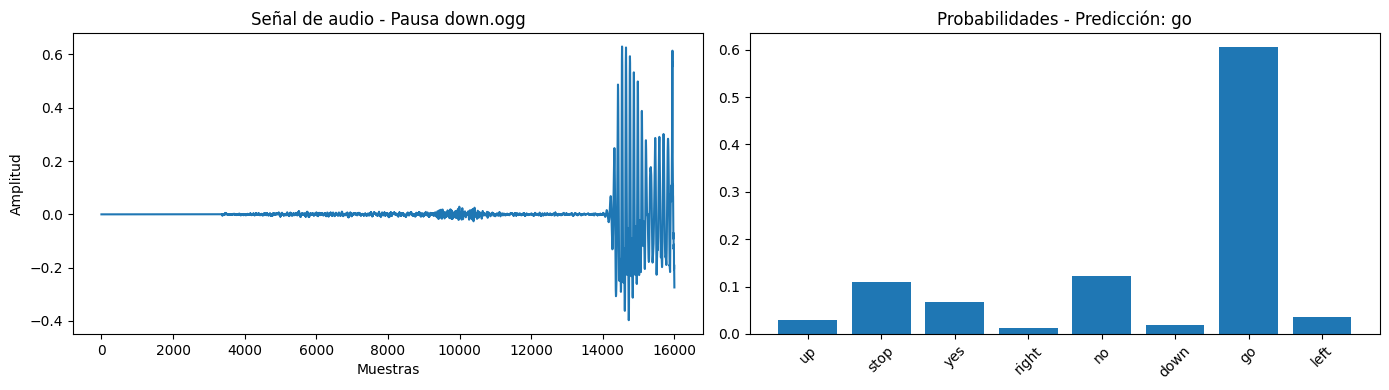


Resumen de audios externos:
Pausa down.ogg -> go


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")

Saving Left.ogg to Left.ogg
Archivo: Left.ogg
Predicción: no  (confianza: 100.00%)


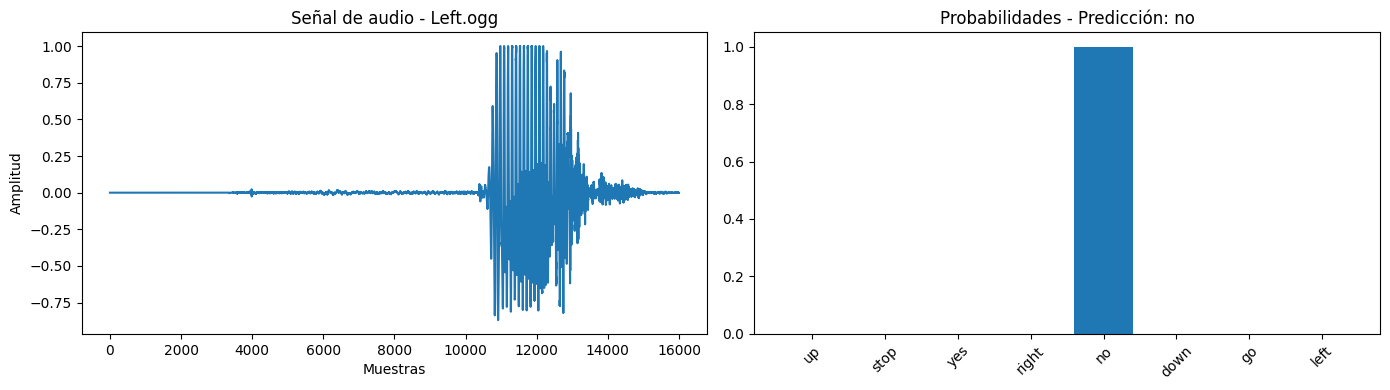


Resumen de audios externos:
Left.ogg -> no


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")

Saving yes.ogg to yes.ogg
Archivo: yes.ogg
Predicción: left  (confianza: 47.93%)


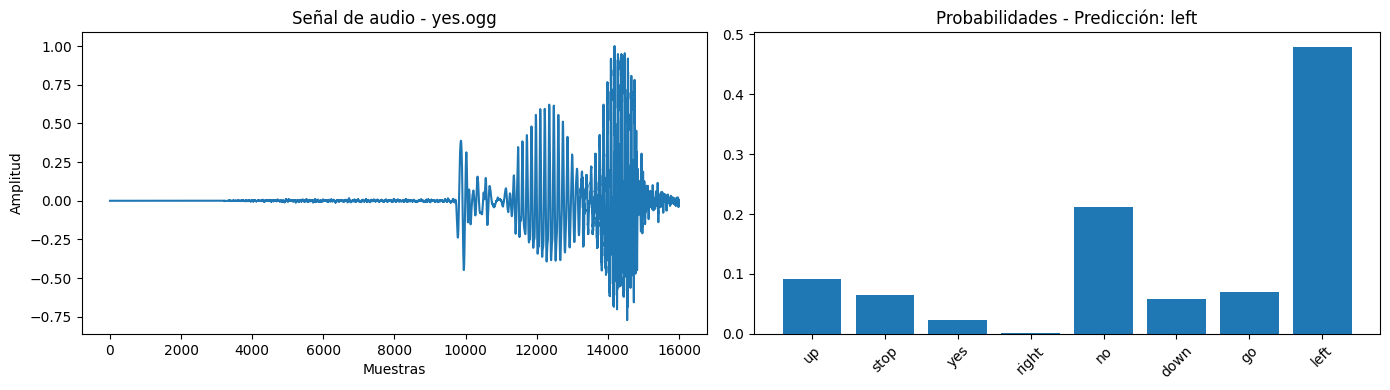


Resumen de audios externos:
yes.ogg -> left


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")

Saving stop.ogg to stop.ogg
Archivo: stop.ogg
Predicción: yes  (confianza: 55.20%)


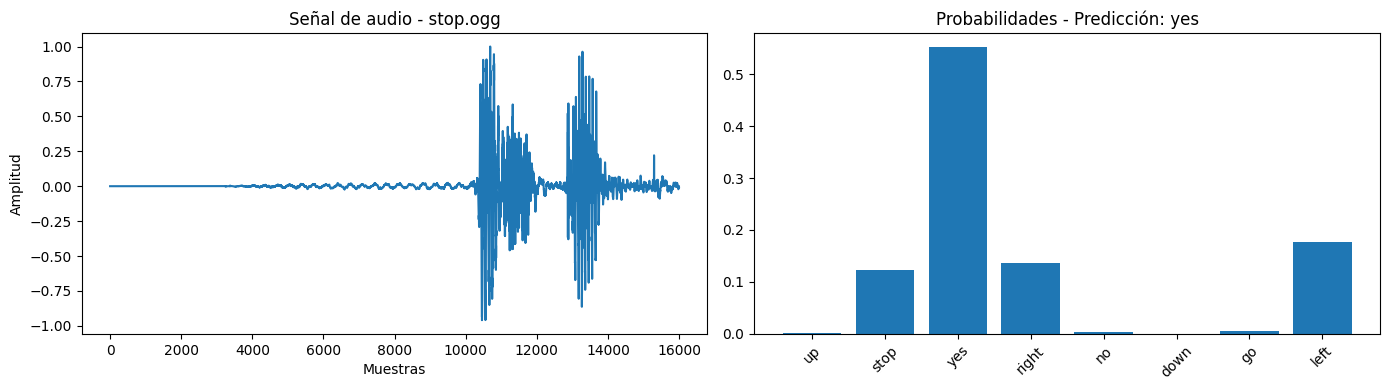


Resumen de audios externos:
stop.ogg -> yes


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")

Saving LEFT pronunciado.ogg to LEFT pronunciado.ogg
Archivo: LEFT pronunciado.ogg
Predicción: left  (confianza: 100.00%)


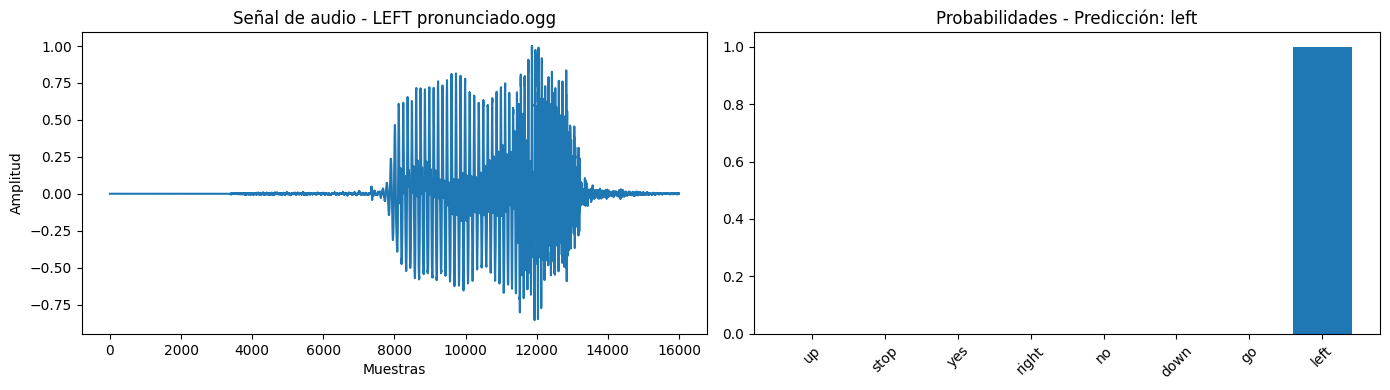


Resumen de audios externos:
LEFT pronunciado.ogg -> left


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")

Saving YES pronunciado.ogg to YES pronunciado.ogg
Archivo: YES pronunciado.ogg
Predicción: yes  (confianza: 100.00%)


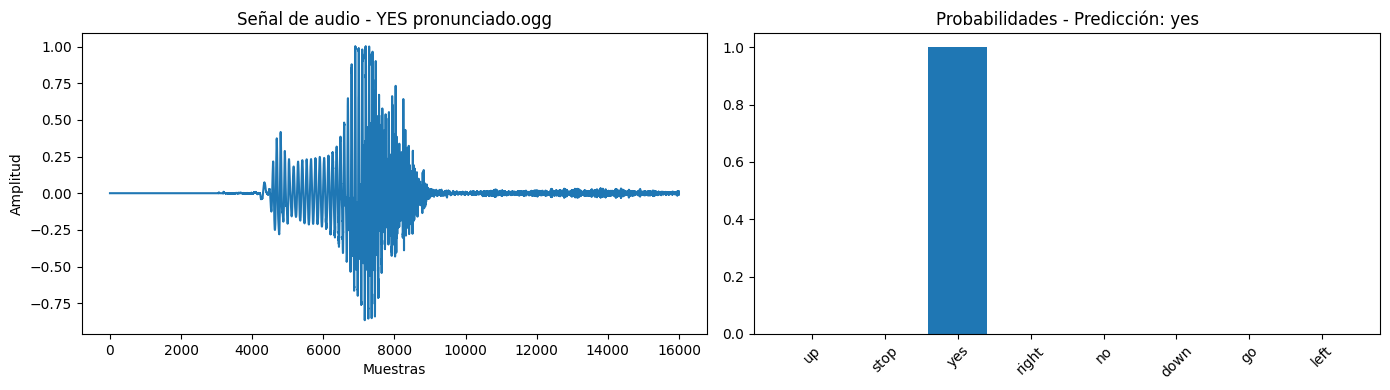


Resumen de audios externos:
YES pronunciado.ogg -> yes


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")

Saving LEFT bien pronunciado.mp4 to LEFT bien pronunciado.mp4
Archivo: LEFT bien pronunciado.mp4
Predicción: left  (confianza: 99.94%)


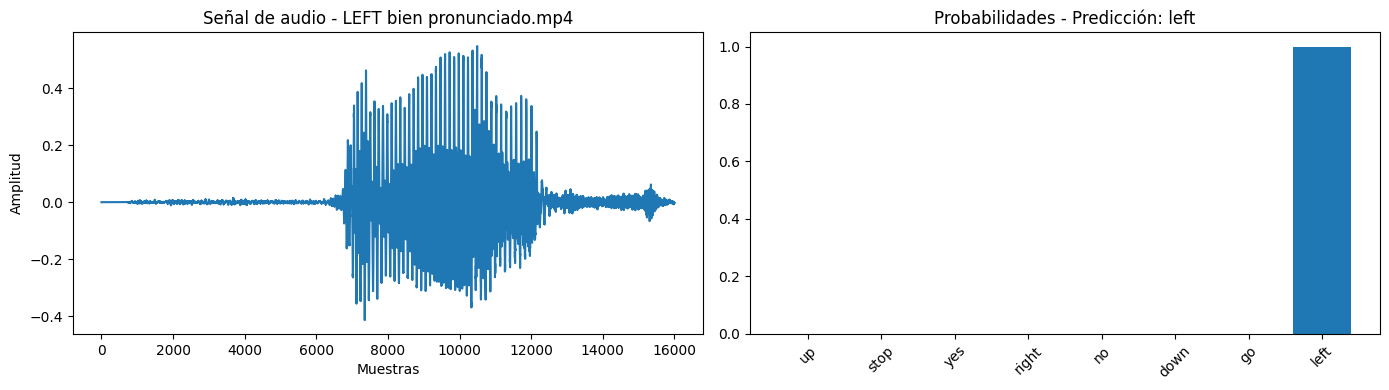


Resumen de audios externos:
LEFT bien pronunciado.mp4 -> left


In [ ]:
from google.colab import files
import subprocess

# Asegurar que ffmpeg esté disponible (Colab ya lo trae, pero por si acaso)
!apt-get -qq install -y ffmpeg > /dev/null

def convertir_a_wav16k(input_path):
    """Convierte cualquier audio a WAV mono 16kHz, requerido por el modelo."""
    output_path = os.path.splitext(input_path)[0] + "_16k.wav"
    comando = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", "16000", "-ac", "1",
        output_path
    ]
    resultado = subprocess.run(comando, capture_output=True, text=True)
    if resultado.returncode != 0:
        print("Error en conversión ffmpeg:")
        print(resultado.stderr)
        return None
    return output_path

def predecir_audio(file_path, verdadero_label=None):
    # Convertir siempre a wav 16k mono antes de decodificar
    wav_path = convertir_a_wav16k(file_path)
    if wav_path is None:
        print(f"No se pudo procesar {file_path}")
        return None

    audio_binary = tf.io.read_file(wav_path)
    waveform = decode_audio(audio_binary)
    spectrogram = get_spectrogram(waveform)
    spectrogram = tf.expand_dims(spectrogram, 0)  # batch de 1

    pred = model.predict(spectrogram, verbose=0)
    pred_label = commands[np.argmax(pred)]
    confianza = np.max(pred)

    print(f"Archivo: {file_path}")
    print(f"Predicción: {pred_label}  (confianza: {confianza:.2%})")
    if verdadero_label:
        correcto = "✅" if pred_label == verdadero_label else "❌"
        print(f"Etiqueta real: {verdadero_label}  {correcto}")

    # --- Graficar señal de audio + distribución de probabilidades juntas ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(waveform.numpy())
    axes[0].set_title(f"Señal de audio - {os.path.basename(file_path)}")
    axes[0].set_xlabel("Muestras")
    axes[0].set_ylabel("Amplitud")

    axes[1].bar(commands, pred[0])
    axes[1].set_title(f"Probabilidades - Predicción: {pred_label}")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return pred_label

# Subir tus propios audios (cualquier formato: ogg, mp3, wav, m4a...)
uploaded = files.upload()

resultados_externos = []
for fname in uploaded.keys():
    # Cambia "verdadero_label" según lo que grabaste, ej: "yes", "no", "stop", etc.
    label_pred = predecir_audio(fname, verdadero_label=None)
    resultados_externos.append((fname, label_pred))

print("\nResumen de audios externos:")
for f, l in resultados_externos:
    print(f"{f} -> {l}")